## Laboratoriska Vezba #4

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data'
columns = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

df = pd.read_csv(url, header=None, names=columns)
print('Shape:', df.shape)
df.head()

Shape: (1728, 7)


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [3]:
print("Информации:")
df.info()

print("\nUnique вредности по колона:")
print(df.nunique())

print("\nРаспределба на класата:")
print(df['class'].value_counts())

Информации:
<class 'pandas.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   str  
 1   maint     1728 non-null   str  
 2   doors     1728 non-null   str  
 3   persons   1728 non-null   str  
 4   lug_boot  1728 non-null   str  
 5   safety    1728 non-null   str  
 6   class     1728 non-null   str  
dtypes: str(7)
memory usage: 94.6 KB

Unique вредности по колона:
buying      4
maint       4
doors       4
persons     3
lug_boot    3
safety      3
class       4
dtype: int64

Распределба на класата:
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


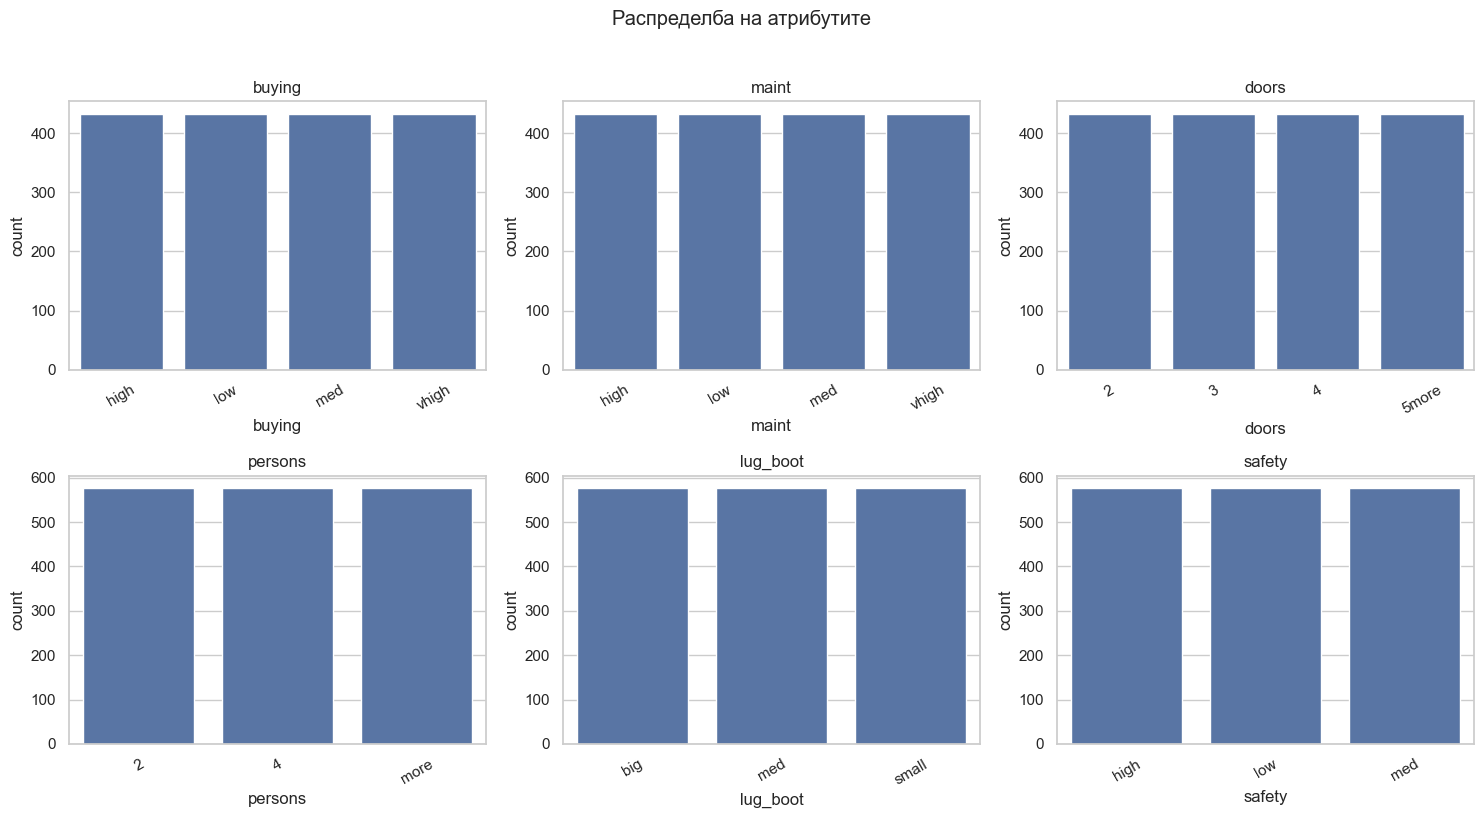

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), columns[:-1]):
    sns.countplot(data=df, x=col, ax=ax, order=sorted(df[col].unique()))
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Распределба на атрибутите', y=1.02)
plt.tight_layout()
plt.show()

In [5]:
X = df.drop('class', axis=1)
y = df['class']

le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Класи:", list(le.classes_))

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=42, stratify=y_enc
)
print("Train:", X_train.shape, "| Test:", X_test.shape)

cat_cols = X.columns.tolist()

ordinal_prep = ColumnTransformer([('cat', OrdinalEncoder(), cat_cols)])
onehot_prep  = ColumnTransformer([('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)])

Класи: ['acc', 'good', 'unacc', 'vgood']
Train: (1382, 6) | Test: (346, 6)


## Decision tree experimentation

In [6]:
dt_grid = {
    'clf__max_depth':        [None, 3, 5, 7, 9],
    'clf__min_samples_split': [2, 5, 10],
    'clf__criterion':        ['gini', 'entropy']
}

dt_pipe = Pipeline([
    ('prep', ordinal_prep),
    ('clf',  DecisionTreeClassifier(random_state=42))
])

dt_results = []
for params in ParameterGrid(dt_grid):
    dt_pipe.set_params(**params)
    dt_pipe.fit(X_train, y_train)
    p = dt_pipe.predict(X_test)
    dt_results.append({**params,
        'accuracy':  accuracy_score(y_test, p),
        'f1_macro':  f1_score(y_test, p, average='macro', zero_division=0)
    })

dt_df = pd.DataFrame(dt_results).sort_values('f1_macro', ascending=False)
dt_df.head(10)

,clf__criterion,clf__max_depth,clf__min_samples_split,accuracy,f1_macro
16,entropy,NaN,5,0.988439,0.975802
1,gini,NaN,5,0.982659,0.971399
0,gini,NaN,2,0.985549,0.961547
15,entropy,NaN,2,0.979769,0.932424
2,gini,NaN,10,0.959538,0.900141
17,entropy,NaN,10,0.962428,0.884651
12,gini,9.0,2,0.953757,0.864736
14,gini,9.0,10,0.950867,0.862558
13,gini,9.0,5,0.950867,0.862558
29,entropy,9.0,10,0.953757,0.840605


## Decision tree 

In [7]:
best = dt_df.iloc[0]

best_dt = Pipeline([
    ('prep', ordinal_prep),
    ('clf',  DecisionTreeClassifier(
        random_state=42,
        max_depth=None if pd.isna(best['clf__max_depth']) else best['clf__max_depth'],
        min_samples_split=int(best['clf__min_samples_split']),
        criterion=best['clf__criterion']
    ))
])
best_dt.fit(X_train, y_train)
dt_preds = best_dt.predict(X_test)

print(classification_report(y_test, dt_preds, target_names=le.classes_))

              precision    recall  f1-score   support

         acc       0.97      0.97      0.97        77
        good       0.88      1.00      0.93        14
       unacc       1.00      0.99      1.00       242
       vgood       1.00      1.00      1.00        13

    accuracy                           0.99       346
   macro avg       0.96      0.99      0.98       346
weighted avg       0.99      0.99      0.99       346



## Decision tree feature importance


    feature  importance
5    safety    0.259532
1     maint    0.211019
3   persons    0.207470
0    buying    0.162480
4  lug_boot    0.097472
2     doors    0.062028


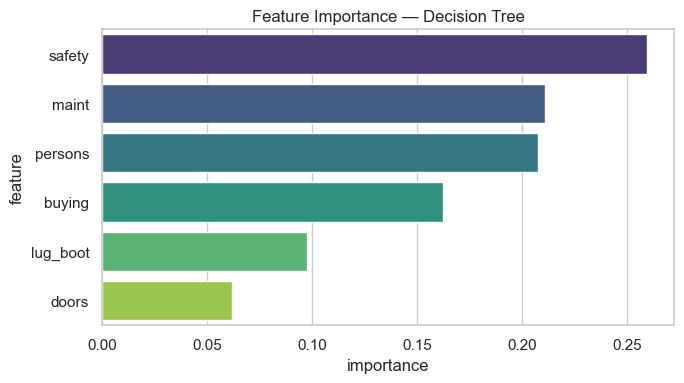

In [8]:
imp = pd.DataFrame({
    'feature':    cat_cols,
    'importance': best_dt.named_steps['clf'].feature_importances_
}).sort_values('importance', ascending=False)

print(imp)

plt.figure(figsize=(7, 4))
sns.barplot(data=imp, x='importance', y='feature', palette='viridis')
plt.title('Feature Importance — Decision Tree')
plt.tight_layout()
plt.show()

## Random forest experimentation

In [11]:
rf_grid = {
    'clf__n_estimators': [50, 100, 300],
    'clf__max_features': ['sqrt', 'log2', None],
    'clf__bootstrap':    [True, False],
    'clf__max_depth':    [None, 5, 10]
}

rf_pipe = Pipeline([
    ('prep', ordinal_prep),
    ('clf',  RandomForestClassifier(random_state=42))
])

rf_results = []
for params in ParameterGrid(rf_grid):
    rf_pipe.set_params(**params)
    rf_pipe.fit(X_train, y_train)
    p = rf_pipe.predict(X_test)
    rf_results.append({**params,
        'accuracy': accuracy_score(y_test, p),
        'f1_macro': f1_score(y_test, p, average='macro', zero_division=0)
    })

rf_df = pd.DataFrame(rf_results).sort_values('f1_macro', ascending=False)
rf_df.head(10)

,clf__bootstrap,clf__max_depth,clf__max_features,clf__n_estimators,accuracy,f1_macro
7,True,NaN,NaN,100,0.991329,0.975962
6,True,NaN,NaN,50,0.991329,0.975962
8,True,NaN,NaN,300,0.988439,0.973853
34,False,NaN,NaN,100,0.982659,0.969689
3,True,NaN,log2,50,0.979769,0.967078
0,True,NaN,sqrt,50,0.979769,0.967078
29,False,NaN,sqrt,300,0.988439,0.965134
32,False,NaN,log2,300,0.988439,0.965134
45,False,10.0,sqrt,50,0.985549,0.963125
48,False,10.0,log2,50,0.985549,0.963125


## Random forest

In [16]:
best_rf_p = rf_df.iloc[0]

best_rf = Pipeline([
    ('prep', ordinal_prep),
    ('clf',  RandomForestClassifier(
        random_state=42,
        n_estimators=int(best_rf_p['clf__n_estimators']),
        max_features= 10, #best_rf_p['clf__max_features'], POPRAVI GO OVA !!!!!
        bootstrap=bool(best_rf_p['clf__bootstrap']),
        max_depth=None if pd.isna(best_rf_p['clf__max_depth']) else int(best_rf_p['clf__max_depth'])
    ))
])
best_rf.fit(X_train, y_train)
rf_preds = best_rf.predict(X_test)

print(classification_report(y_test, rf_preds, target_names=le.classes_))

              precision    recall  f1-score   support

         acc       0.99      0.97      0.98        77
        good       0.93      1.00      0.97        14
       unacc       1.00      1.00      1.00       242
       vgood       1.00      0.92      0.96        13

    accuracy                           0.99       346
   macro avg       0.98      0.97      0.98       346
weighted avg       0.99      0.99      0.99       346



## Random forest feature importance

    feature  importance
5    safety    0.252786
1     maint    0.212512
0    buying    0.181009
3   persons    0.179813
4  lug_boot    0.110022
2     doors    0.063859


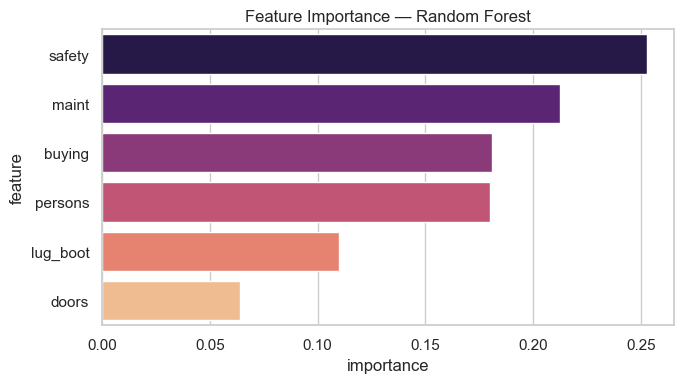

In [17]:
imp_rf = pd.DataFrame({
    'feature':    cat_cols,
    'importance': best_rf.named_steps['clf'].feature_importances_
}).sort_values('importance', ascending=False)

print(imp_rf)

plt.figure(figsize=(7, 4))
sns.barplot(data=imp_rf, x='importance', y='feature', palette='magma')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

## Neural network experimentation

In [18]:
nn_grid = {
    'clf__hidden_layer_sizes': [(32,), (64,), (64, 32), (128, 64)],
    'clf__activation':         ['relu', 'tanh', 'logistic'],
    'clf__learning_rate_init': [0.001, 0.01],
}

nn_pipe = Pipeline([
    ('prep',  onehot_prep),
    ('scale', StandardScaler(with_mean=False)),
    ('clf',   MLPClassifier(max_iter=500, random_state=42, early_stopping=True))
])

nn_results = []
for params in ParameterGrid(nn_grid):
    nn_pipe.set_params(**params)
    nn_pipe.fit(X_train, y_train)
    p = nn_pipe.predict(X_test)
    nn_results.append({
        'hidden_layer_sizes': str(params['clf__hidden_layer_sizes']),
        'activation':         params['clf__activation'],
        'learning_rate_init': params['clf__learning_rate_init'],
        'accuracy':  accuracy_score(y_test, p),
        'f1_macro':  f1_score(y_test, p, average='macro', zero_division=0)
    })

nn_df = pd.DataFrame(nn_results).sort_values('f1_macro', ascending=False)
nn_df.head(10)

,hidden_layer_sizes,activation,learning_rate_init,accuracy,f1_macro
15,"(128, 64)",tanh,0.010,1.000000,1.000000
3,"(64,)",relu,0.010,0.991329,0.993608
23,"(128, 64)",logistic,0.010,0.988439,0.982852
13,"(64, 32)",tanh,0.010,0.991329,0.976723
11,"(64,)",tanh,0.010,0.988439,0.966426
14,"(128, 64)",tanh,0.001,0.988439,0.964582
9,"(32,)",tanh,0.010,0.985549,0.964180
7,"(128, 64)",relu,0.010,0.982659,0.961591
5,"(64, 32)",relu,0.010,0.979769,0.960120
6,"(128, 64)",relu,0.001,0.982659,0.958973


## Neural network

In [19]:
best_nn_p = nn_df.iloc[0]

best_nn = Pipeline([
    ('prep',  onehot_prep),
    ('scale', StandardScaler(with_mean=False)),
    ('clf',   MLPClassifier(
        max_iter=500, random_state=42, early_stopping=True,
        hidden_layer_sizes=eval(best_nn_p['hidden_layer_sizes']),
        activation=best_nn_p['activation'],
        learning_rate_init=float(best_nn_p['learning_rate_init'])
    ))
])
best_nn.fit(X_train, y_train)
nn_preds = best_nn.predict(X_test)

print(classification_report(y_test, nn_preds, target_names=le.classes_))

              precision    recall  f1-score   support

         acc       1.00      1.00      1.00        77
        good       1.00      1.00      1.00        14
       unacc       1.00      1.00      1.00       242
       vgood       1.00      1.00      1.00        13

    accuracy                           1.00       346
   macro avg       1.00      1.00      1.00       346
weighted avg       1.00      1.00      1.00       346



## Neural network: loss curve

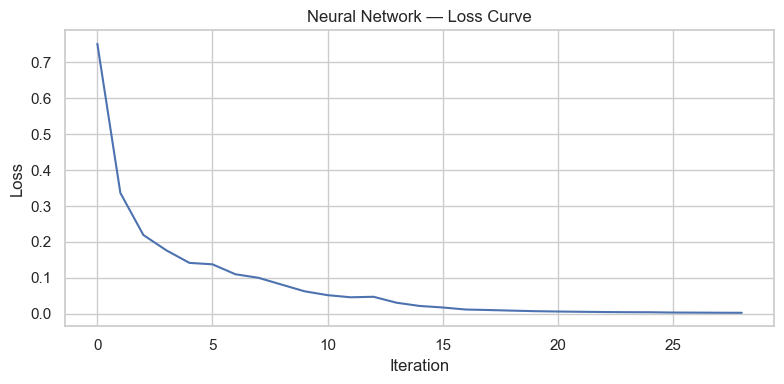

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(best_nn.named_steps['clf'].loss_curve_)
plt.title('Neural Network — Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

## Sporedba

In [21]:
def eval_model(name, preds):
    return {
        'Model':              name,
        'Accuracy':           accuracy_score(y_test, preds),
        'Precision (macro)':  precision_score(y_test, preds, average='macro', zero_division=0),
        'Recall (macro)':     recall_score(y_test, preds, average='macro', zero_division=0),
        'F1-score (macro)':   f1_score(y_test, preds, average='macro', zero_division=0)
    }

comparison = pd.DataFrame([
    eval_model('Decision Tree',  dt_preds),
    eval_model('Random Forest',  rf_preds),
    eval_model('Neural Network', nn_preds)
]).sort_values('F1-score (macro)', ascending=False)

comparison

,Model,Accuracy,Precision (macro),Recall (macro),F1-score (macro)
2,Neural Network,1.000000,1.000000,1.000000,1.000000
1,Random Forest,0.991329,0.979015,0.974276,0.975962
0,Decision Tree,0.988439,0.962256,0.991440,0.975802


## Matrica na konfuzija

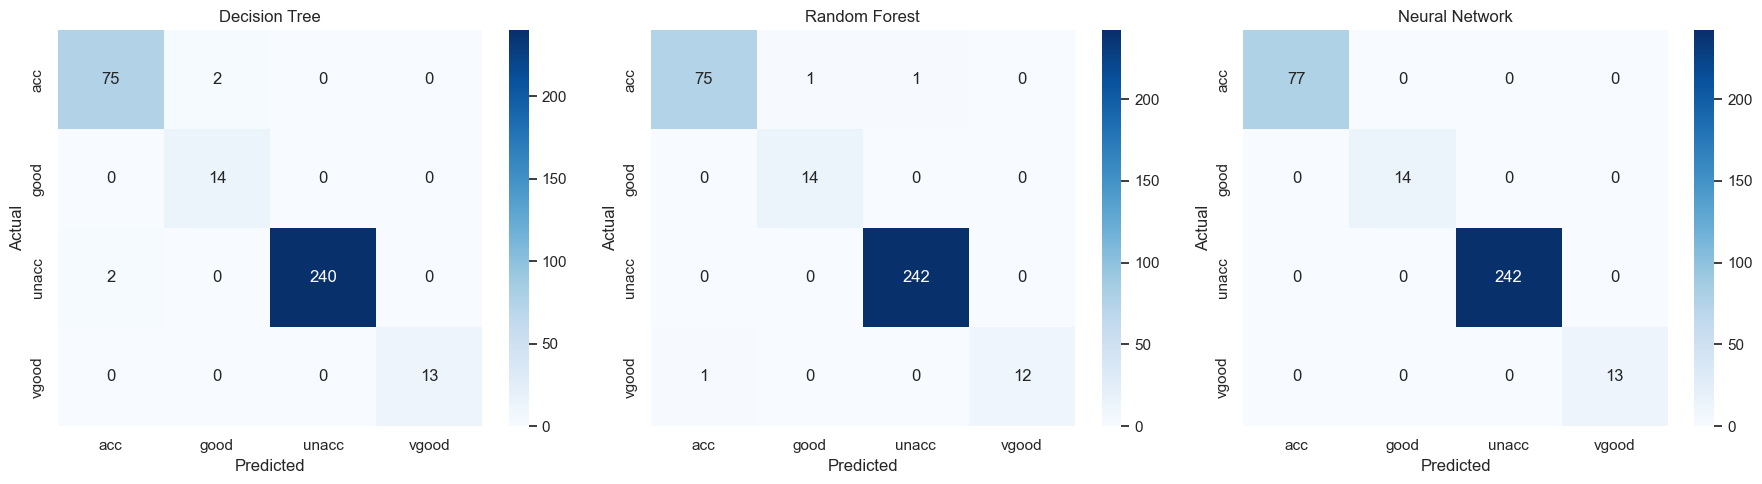

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, preds, title in zip(axes,
                             [dt_preds, rf_preds, nn_preds],
                             ['Decision Tree', 'Random Forest', 'Neural Network']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

## Baren dijagram

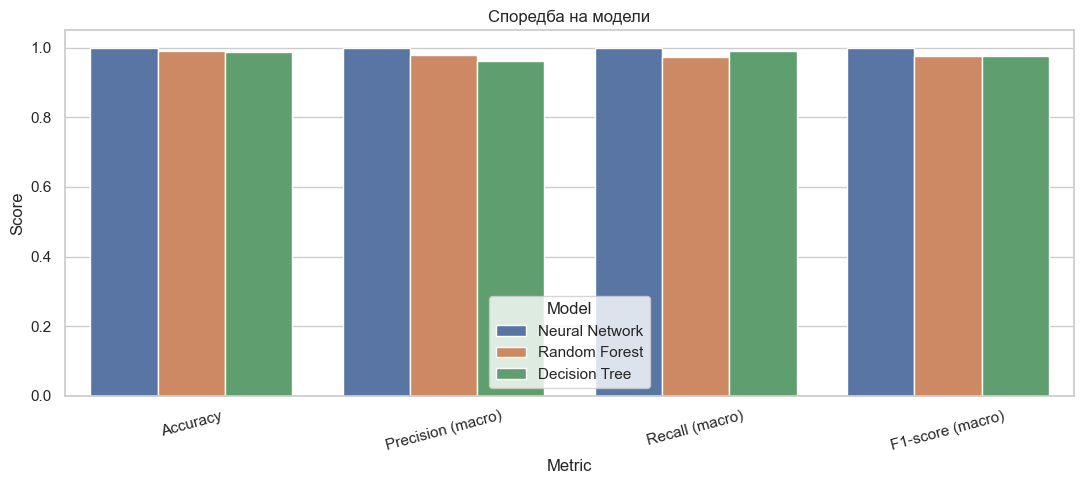

In [23]:
melted = comparison.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(11, 5))
sns.barplot(data=melted, x='Metric', y='Score', hue='Model')
plt.ylim(0, 1.05)
plt.title('Споредба на модели')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Diskusija

In [24]:
# Decision Tree
# Предности: интерпретабилен, визуелизабилен, брз за тренирање
# Недостатоци: overfitting при голема длабочина, нестабилен

# Random Forest
# Предности: стабилен, висока точност, добро ги намалува variance и bias
# Недостатоци: потешко за интерпретација, побавен

# Neural Network
# Предности: флексибилен, може да учи сложени релации
# Недостатоци: бара повеќе tuning, тешко за интерпретација, потребен preprocessing